**Environment & Setup**

In [ ]:
# ============================================================
# Heart Disease Risk Prediction - Research Model
# Author: Ravi Teja Pingili
# Objective: Comparative ML & DL Modeling for Heart Disease
# ============================================================

# ------------------------
# 1. Import Libraries
# ------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Explainable AI
import shap

**Mount Google Drive (Clean Version)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Dataset**

In [ ]:
data_path = "/content/drive/MyDrive/Dataset/heart_disease.csv"
df = pd.read_csv(data_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (10000, 21)


**Dataset Overview**

In [ ]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [ ]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [ ]:
df.describe(include='object')

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Heart Disease Status
count,9981,9975,9975,9979,9970,9974,9975,9974,7414,9978,9970,10000
unique,2,3,2,2,2,2,2,2,3,3,3,2
top,Male,High,Yes,No,No,Yes,Yes,No,Medium,Medium,Low,No
freq,5003,3372,5123,5004,5018,5022,5000,5036,2500,3387,3390,8000


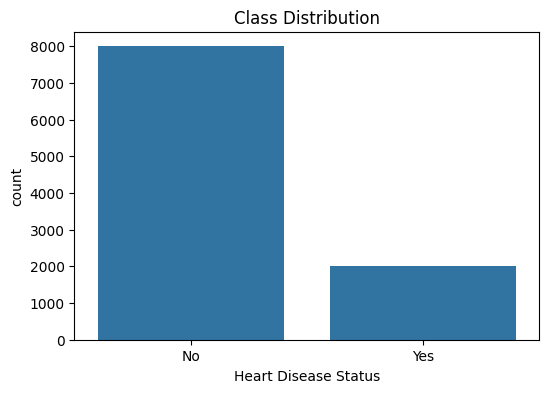

,proportion
Heart Disease Status,
No,0.8
Yes,0.2


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Heart Disease Status', data=df)
plt.title("Class Distribution")
plt.show()

df['Heart Disease Status'].value_counts(normalize=True)

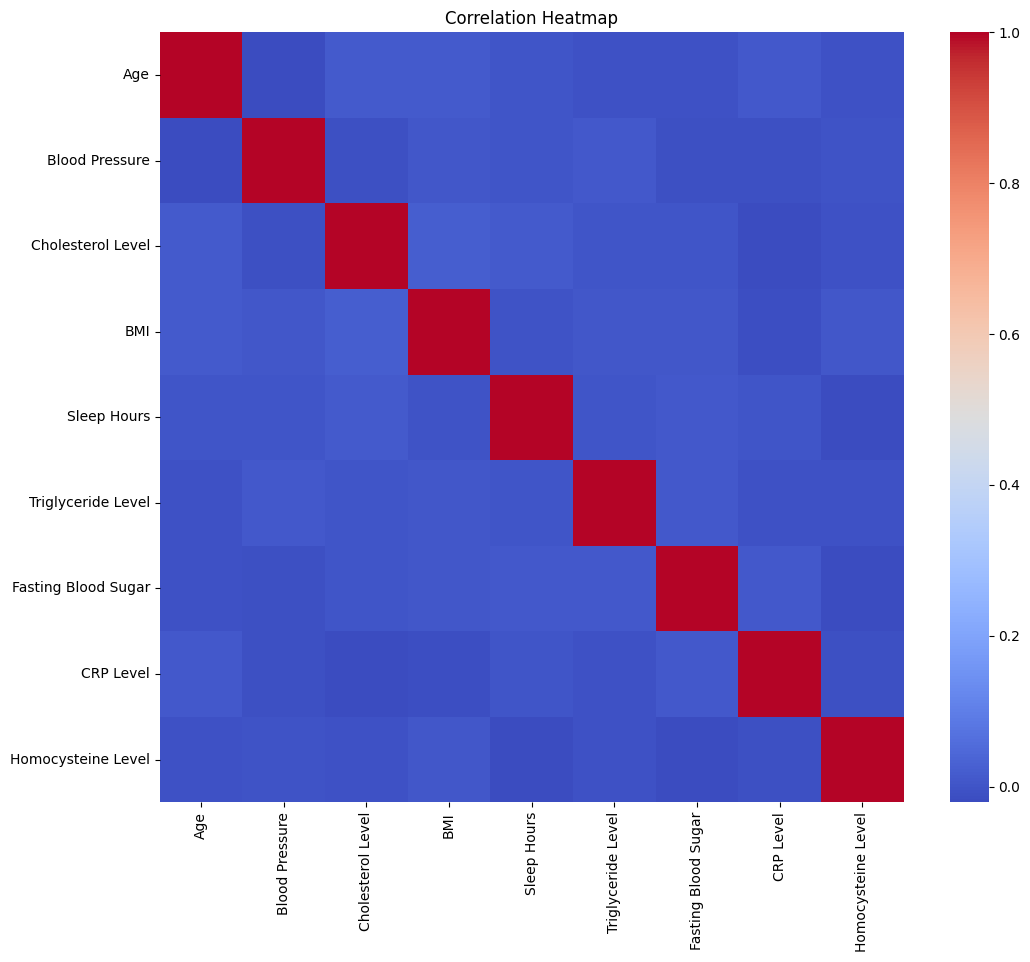

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

**Numerical Features**

**Missing Value Analysis**

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


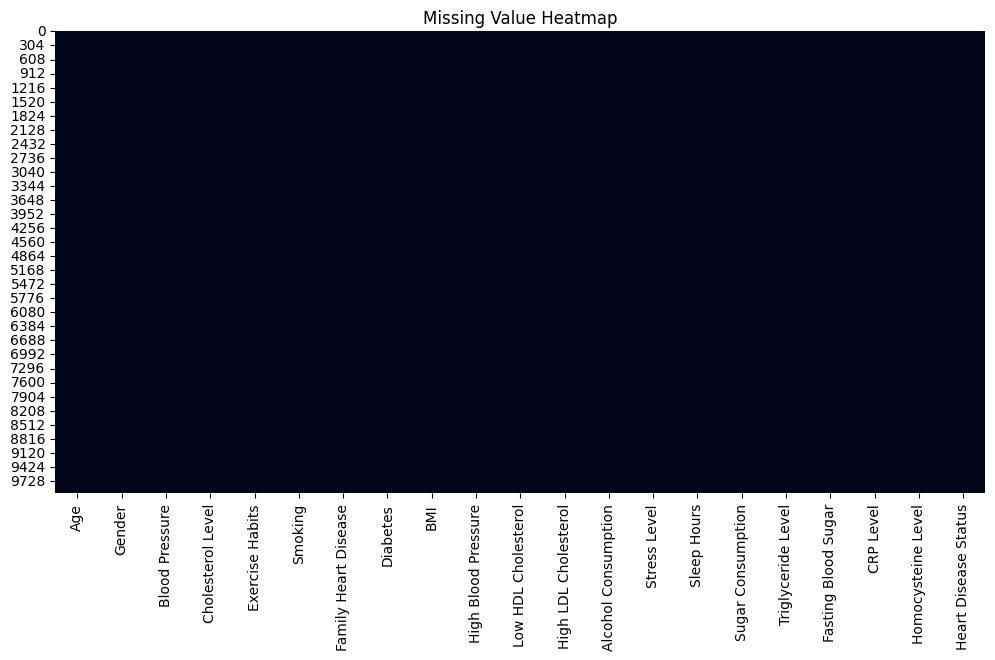

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [ ]:
# Numerical Imputation
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Imputation
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


**Numerical Feature Distributions**

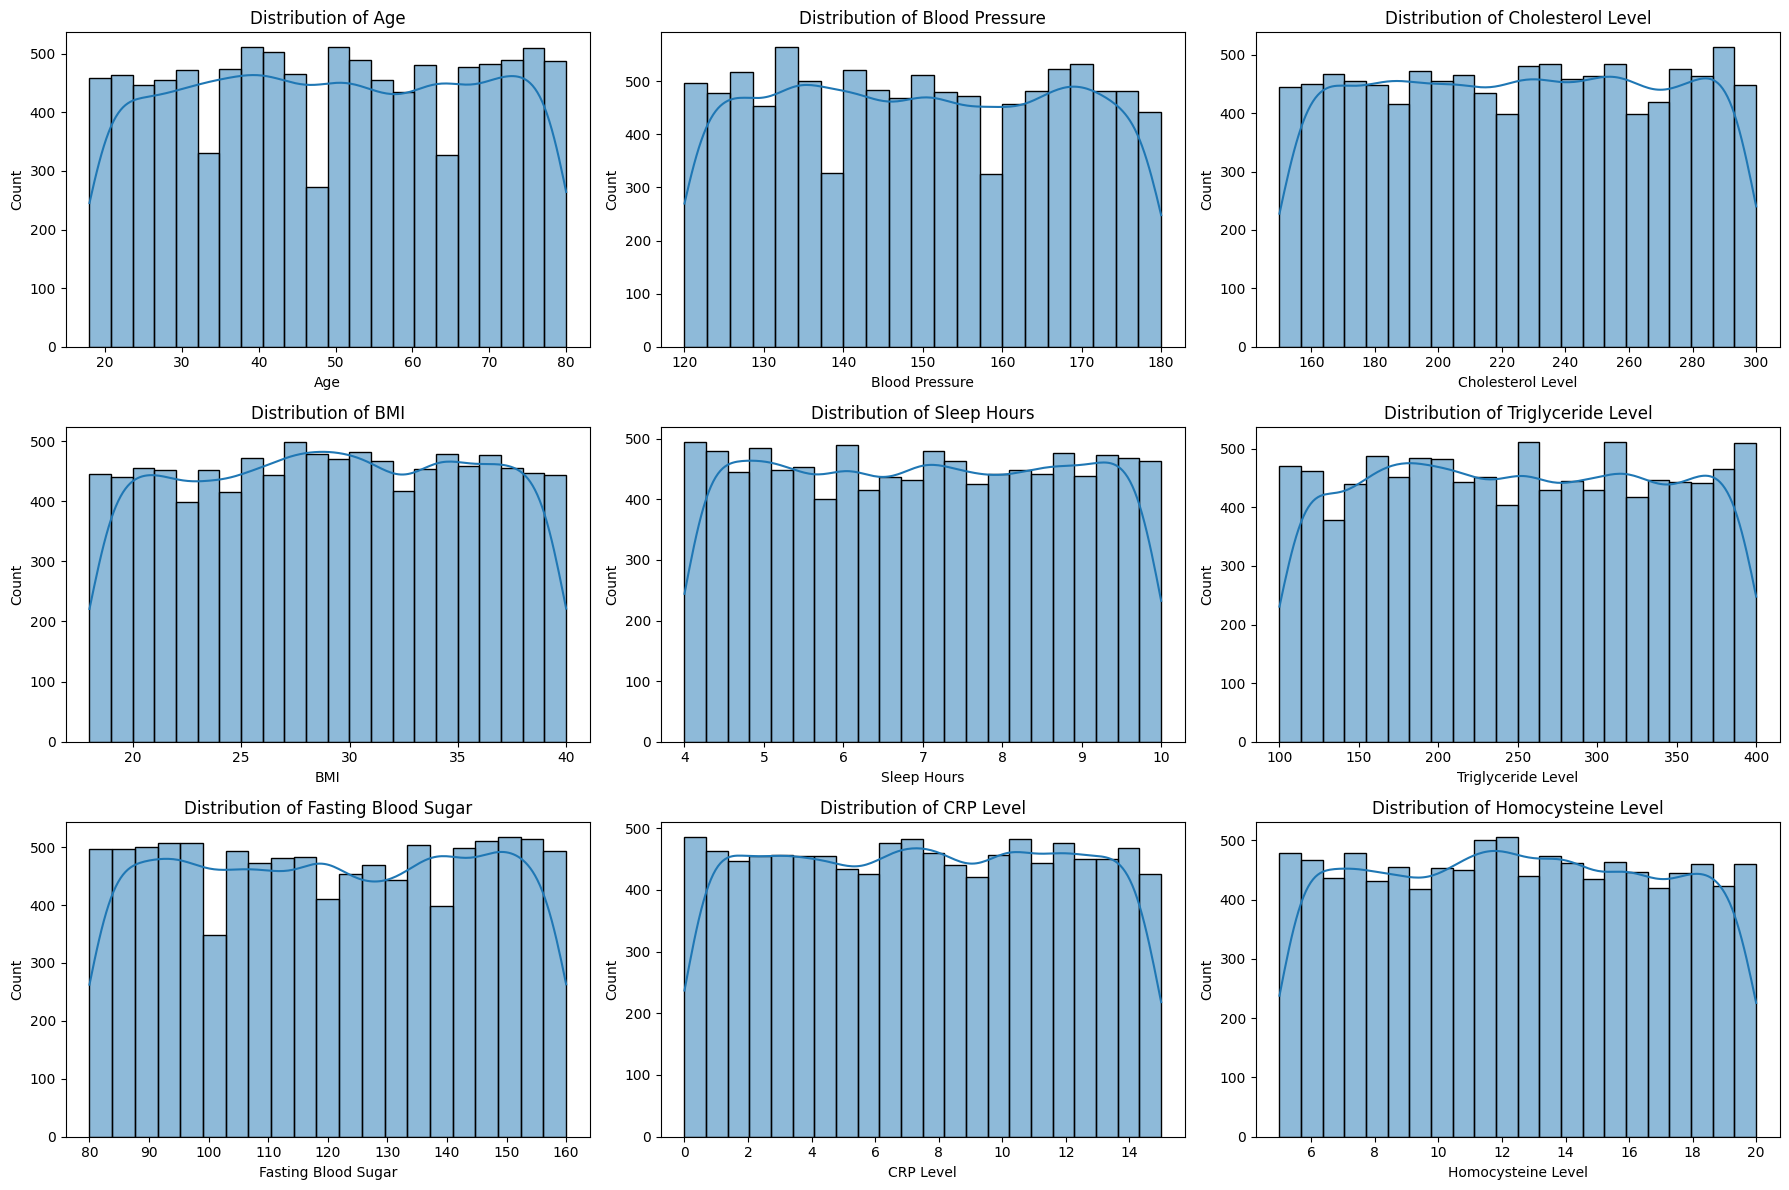

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = [col for col in num_cols if col != 'Heart Disease Status']

plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

**Target vs Numerical Features**

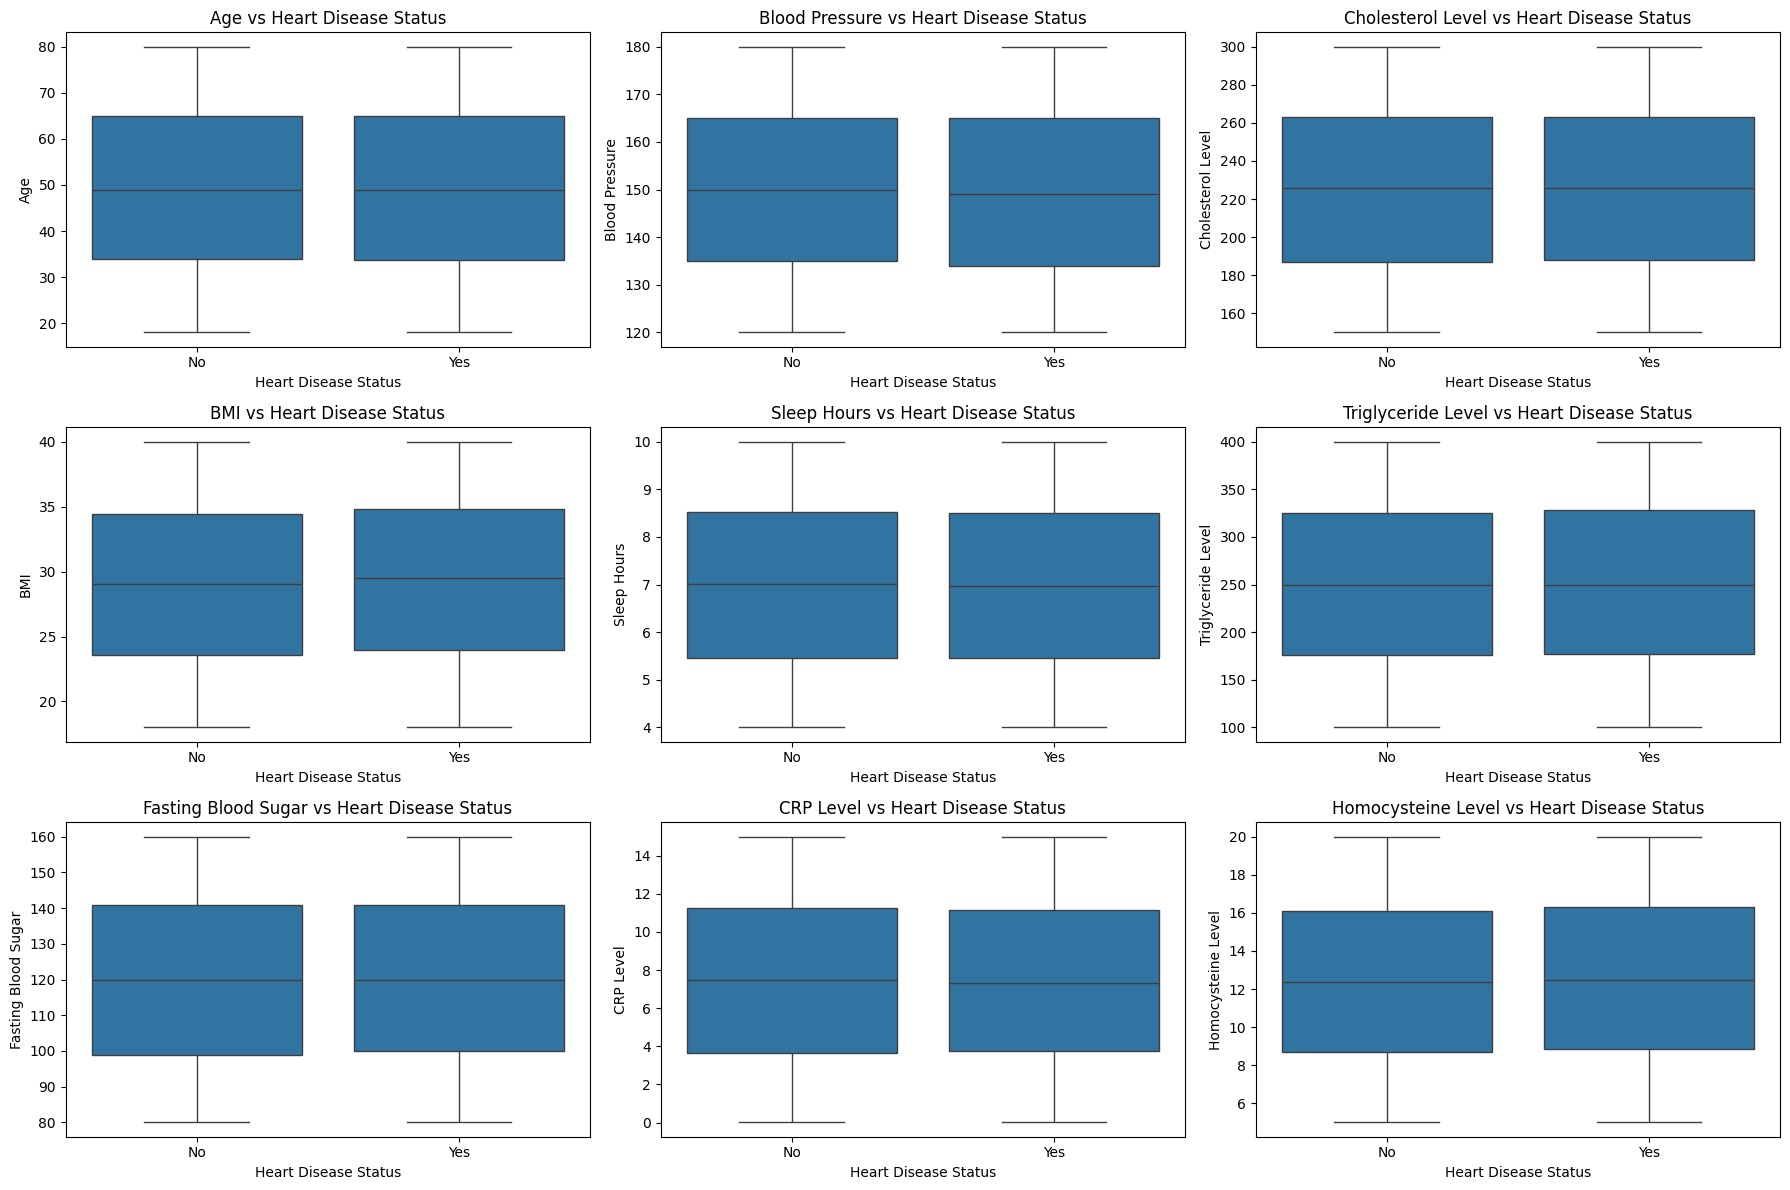

In [ ]:
plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Heart Disease Status', y=col, data=df)
    plt.title(f"{col} vs Heart Disease Status")

plt.tight_layout()
plt.show()

**Categorical Features vs Target**

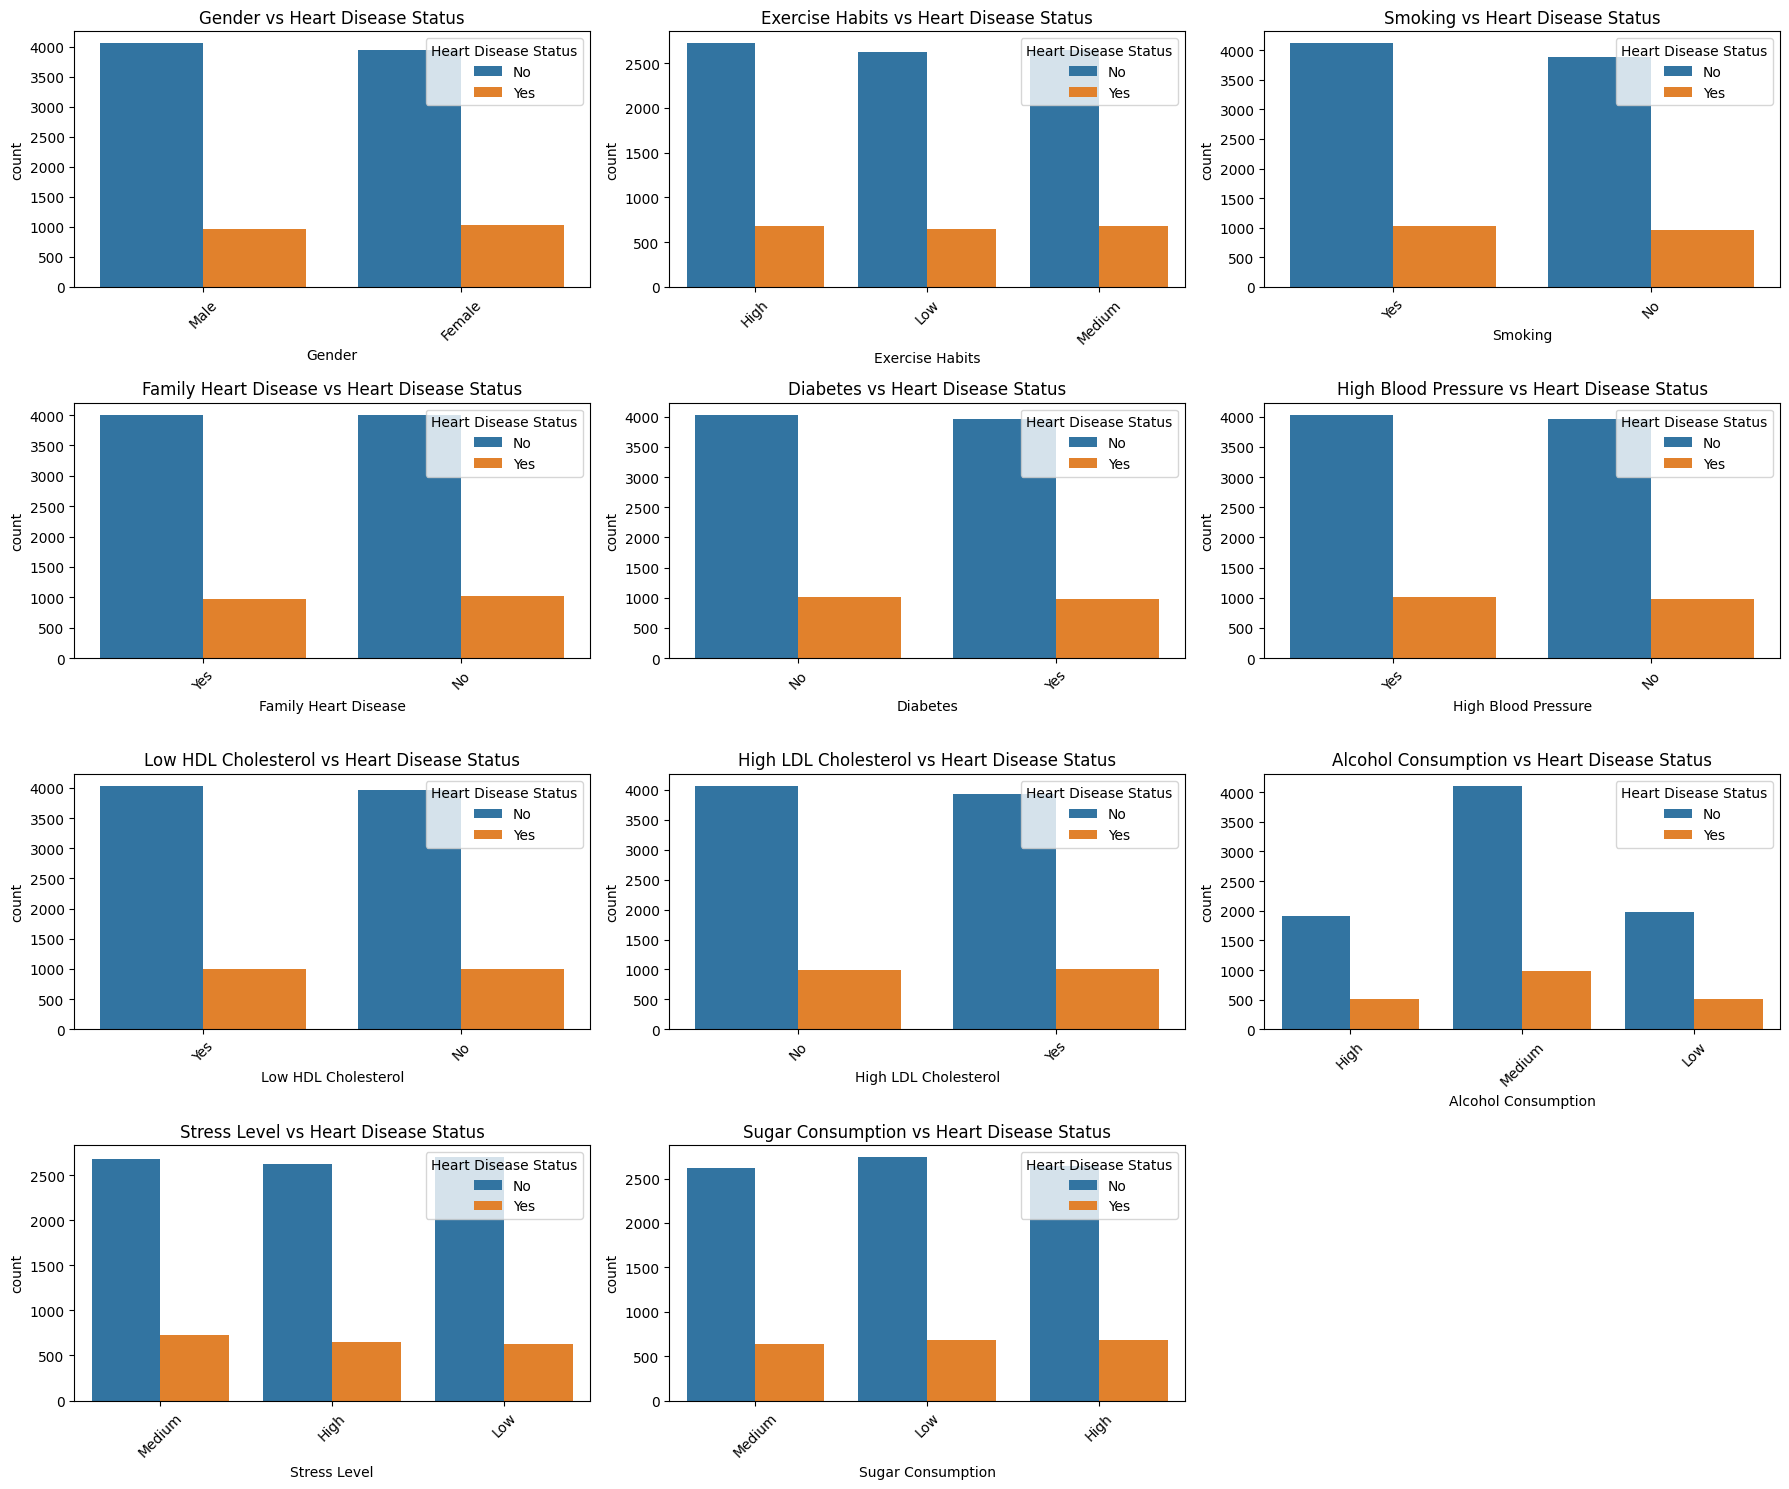

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols = [col for col in cat_cols if col != 'Heart Disease Status']

plt.figure(figsize=(18,15))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, hue='Heart Disease Status', data=df)
    plt.title(f"{col} vs Heart Disease Status")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Correlation of Features with Target**

In [ ]:
df['Heart Disease Status'] = df['Heart Disease Status'].map({'No':0, 'Yes':1})

In [ ]:
corr = df.corr(numeric_only=True)['Heart Disease Status'].sort_values(ascending=False)
corr

,Heart Disease Status
Heart Disease Status,1.000000
BMI,0.019682
Homocysteine Level,0.008302
Triglyceride Level,0.002904
Cholesterol Level,0.002703
Fasting Blood Sugar,-0.002248
Sleep Hours,-0.003821
CRP Level,-0.006009
Age,-0.009231
Blood Pressure,-0.013876


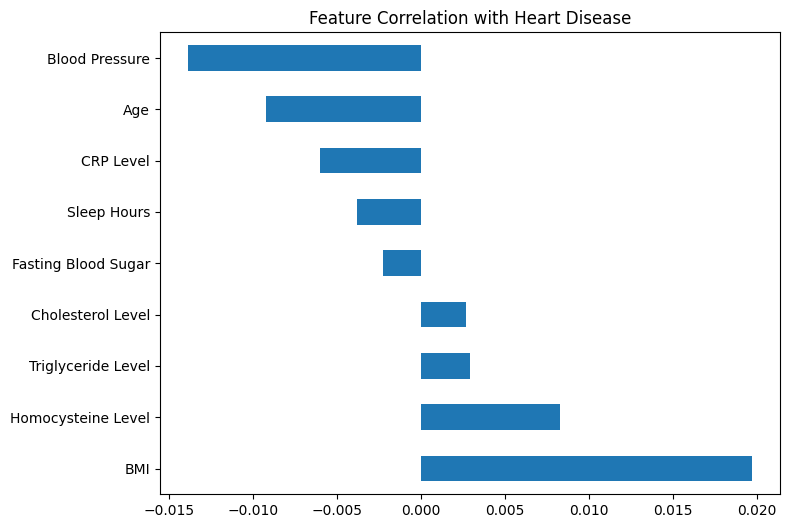

In [ ]:
plt.figure(figsize=(8,6))
corr.drop('Heart Disease Status').plot(kind='barh')
plt.title("Feature Correlation with Heart Disease")
plt.show()